# Differentially Private Logistic Regression - Cancer Risk Dataset

This notebook:
- Loads preprocessed data from data_preprocessor.ipynb
- Loads baseline results from STD_LR
- Trains DP Logistic Regression with different epsilon values
- Runs 30 iterations per epsilon to capture DP stochasticity
- Reports mean +/- std for all metrics
- Saves results to JSON with per-run data

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json
import os
import warnings
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from diffprivlib.models import LogisticRegression as DPLogisticRegression
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
# Load data from data_preprocessor.ipynb
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
bounds = data['bounds']
feature_names = data['feature_names']

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)
data_norm = 1.0

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Testing Set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Features: {feature_names}")
print(f"Data norm (max L2): {data_norm:.4f}")

Training Set: 1200 samples
Testing Set: 300 samples
Number of features: 8
Features: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']
Data norm (max L2): 1.0000


## 3. Load Baseline Results

In [3]:
# Load baseline results from STD_LR
baseline_df = pd.read_csv('./output/baseline_results.csv')
baseline_accuracy = baseline_df['accuracy'].values[0]
baseline_f1 = baseline_df['f1_score'].values[0]
baseline_precision = baseline_df['precision'].values[0]
baseline_recall = baseline_df['recall'].values[0]

print("Baseline results loaded successfully!")
print(f"Baseline Accuracy:  {baseline_accuracy:.4f}")
print(f"Baseline F1-Score:  {baseline_f1:.4f}")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall:    {baseline_recall:.4f}")

Baseline results loaded successfully!
Baseline Accuracy:  0.8500
Baseline F1-Score:  0.7926
Baseline Precision: 0.8113
Baseline Recall:    0.7748


## 4. Define Epsilon Values and Run Configuration

Lower epsilon = more privacy, more noise, potentially lower accuracy.  
Higher epsilon = less privacy, less noise, potentially higher accuracy.

We run 30 iterations per epsilon to capture the variance introduced by the DP mechanism.

In [4]:
# Epsilon values to test
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]

N_RUNS = 30  # runs per epsilon to capture DP stochasticity

print(f"Epsilon values: {epsilon_values}")
print(f"Runs per epsilon: {N_RUNS}")
print(f"Total models to train: {len(epsilon_values) * N_RUNS}")

Epsilon values: [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
Runs per epsilon: 30
Total models to train: 450


## 5. Detailed Evaluation at epsilon=1.0 (Multiple Runs)

In [5]:
epsilon = 1.0

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_cms = []

print(f"Training DP Logistic Regression {N_RUNS} times with epsilon={epsilon}...")
print("=" * 80)

detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed = run * 10 + 42

    dp_model = DPLogisticRegression(
        epsilon=epsilon,
        max_iter=1000,
        random_state=seed,
        data_norm=1.0
    )

    _t0 = time.perf_counter()
    dp_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_pred = dp_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    detail_extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    detail_accuracies.append(acc)
    detail_f1s.append(f1)
    detail_precisions.append(prec)
    detail_recalls.append(rec)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {acc:.4f} | F1: {f1:.4f} | "
          f"Prec: {prec:.4f} | Rec: {rec:.4f}")

print("=" * 80)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {np.mean(detail_accuracies):.4f} +/- {np.std(detail_accuracies):.4f}")
print(f"  F1-Score:  {np.mean(detail_f1s):.4f} +/- {np.std(detail_f1s):.4f}")
print(f"  Precision: {np.mean(detail_precisions):.4f} +/- {np.std(detail_precisions):.4f}")
print(f"  Recall:    {np.mean(detail_recalls):.4f} +/- {np.std(detail_recalls):.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Logistic Regression 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.8433 | F1: 0.7911 | Prec: 0.7807 | Rec: 0.8018
  Run  2/30 | Acc: 0.7667 | F1: 0.6957 | Prec: 0.6723 | Rec: 0.7207
  Run  3/30 | Acc: 0.8033 | F1: 0.7511 | Prec: 0.7063 | Rec: 0.8018
  Run  4/30 | Acc: 0.7433 | F1: 0.6419 | Prec: 0.6635 | Rec: 0.6216
  Run  5/30 | Acc: 0.7567 | F1: 0.6697 | Prec: 0.6727 | Rec: 0.6667
  Run  6/30 | Acc: 0.8100 | F1: 0.7574 | Prec: 0.7177 | Rec: 0.8018
  Run  7/30 | Acc: 0.8033 | F1: 0.7065 | Prec: 0.7889 | Rec: 0.6396
  Run  8/30 | Acc: 0.8500 | F1: 0.7805 | Prec: 0.8511 | Rec: 0.7207
  Run  9/30 | Acc: 0.8167 | F1: 0.7489 | Prec: 0.7593 | Rec: 0.7387
  Run 10/30 | Acc: 0.8467 | F1: 0.7850 | Prec: 0.8155 | Rec: 0.7568
  Run 11/30 | Acc: 0.8267 | F1: 0.7500 | Prec: 0.8041 | Rec: 0.7027
  Run 12/30 | Acc: 0.8567 | F1: 0.8106 | Prec: 0.7931 | Rec: 0.8288
  Run 13/30 | Acc: 0.7433 | F1: 0.6484 | Prec: 0.6574 | Rec: 0.6396
  Run 14/30 | Acc: 0.7567 | F1: 0.6473 | Prec: 0.6979 |

In [6]:
# Average confusion matrix at epsilon=1.0
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

print(f"Average Confusion Matrix ({N_RUNS} runs at epsilon={epsilon}):")
print(custom_cm)

# Comparison with baseline
mean_acc = np.mean(detail_accuracies)
accuracy_loss = 1 - mean_acc / baseline_accuracy

print()
print("=" * 60)
print(f"COMPARISON: Standard vs DP Logistic Regression ({N_RUNS} runs)")
print("=" * 60)
print(f"\nStandard Model Accuracy: {baseline_accuracy:.4f}")
print(f"DP Model Accuracy:       {mean_acc:.4f} +/- {np.std(detail_accuracies):.4f}")
print(f"Accuracy Loss (ACL):     {accuracy_loss:.4f} ({accuracy_loss*100:.2f}%)")
print(f"DP Model F1-Score:       {np.mean(detail_f1s):.4f} +/- {np.std(detail_f1s):.4f}")

Average Confusion Matrix (30 runs at epsilon=1.0):
[[ 80  30]
 [ 28 160]]

COMPARISON: Standard vs DP Logistic Regression (30 runs)

Standard Model Accuracy: 0.8500
DP Model Accuracy:       0.8044 +/- 0.0343
Accuracy Loss (ACL):     0.0536 (5.36%)
DP Model F1-Score:       0.7332 +/- 0.0494


## 6. Epsilon vs Accuracy Analysis (Multiple Runs per Epsilon)

Testing different privacy budget (epsilon) values to observe the trade-off between privacy and accuracy. Each epsilon is tested 30 times to capture DP variance.

In [7]:
# Store aggregated results
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
}

# JSON export
all_results = {
    'model_type': 'Differentially Private Logistic Regression',
    'dataset': 'Cancer Risk Prediction',
    'n_samples': X_train.shape[0] + X_test.shape[0],
    'n_features': X_train.shape[1],
    'n_runs_per_epsilon': N_RUNS,
    'epsilon_results': {}
}

print(f"Training DP Logistic Regression with {N_RUNS} runs per epsilon value...")
print("=" * 90)

for eps in epsilon_values:
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_cms = []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42

        dp_model = DPLogisticRegression(
            epsilon=eps,
            max_iter=1000,
            random_state=seed,
            data_norm=1.0
        )

        _t0 = time.perf_counter()
        dp_model.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_cms.append(cm.tolist())
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_model, f'output/model/dp_lr_model_eps_{eps}.pkl')

    # Compute statistics
    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)

    # Store aggregated results
    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    # Store in JSON
    all_results['epsilon_results'][str(eps)] = {
        'epsilon': float(eps),
        'n_runs': N_RUNS,
        'accuracy_mean': acc_mean,
        'accuracy_std': acc_std,
        'f1_mean': f1_mean,
        'f1_std': f1_std,
        'precision_mean': prec_mean,
        'precision_std': prec_std,
        'recall_mean': rec_mean,
        'recall_std': rec_std,
        'per_run_accuracies': run_accuracies,
        'per_run_f1s': run_f1s,
        'per_run_precisions': run_precisions,
        'per_run_recalls': run_recalls,
        'per_run_confusion_matrices': run_cms,
        'parameters': {
            'epsilon': float(eps),
            'max_iter': 1000,
            'n_runs': N_RUNS
        }
    }
    all_results['epsilon_results'][str(eps)].update(extra.summary())
    all_results['epsilon_results'][str(eps)].update(extra.per_run())

    print(f"eps={eps:5.2f} | Acc: {acc_mean:.4f}+/-{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}+/-{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}+/-{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}+/-{rec_std:.4f}")

print("=" * 90)
print("Training complete!")

Training DP Logistic Regression with 30 runs per epsilon value...


Model successfully exported to output/model/dp_lr_model_eps_0.1.pkl
eps= 0.10 | Acc: 0.6158+/-0.0809 | F1: 0.4931+/-0.1042 | Prec: 0.4957+/-0.0983 | Rec: 0.5192+/-0.1559
Model successfully exported to output/model/dp_lr_model_eps_0.2.pkl
eps= 0.20 | Acc: 0.6691+/-0.0700 | F1: 0.5510+/-0.0980 | Prec: 0.5580+/-0.0942 | Rec: 0.5565+/-0.1275
Model successfully exported to output/model/dp_lr_model_eps_0.4.pkl


eps= 0.40 | Acc: 0.7388+/-0.0602 | F1: 0.6399+/-0.0859 | Prec: 0.6546+/-0.0861 | Rec: 0.6321+/-0.1056
Model successfully exported to output/model/dp_lr_model_eps_0.6.pkl
eps= 0.60 | Acc: 0.7806+/-0.0437 | F1: 0.6967+/-0.0626 | Prec: 0.7143+/-0.0663 | Rec: 0.6841+/-0.0794
Model successfully exported to output/model/dp_lr_model_eps_0.8.pkl
eps= 0.80 | Acc: 0.7338+/-0.0605 | F1: 0.6396+/-0.0877 | Prec: 0.6410+/-0.0831 | Rec: 0.6453+/-0.1141
Model successfully exported to output/model/dp_lr_model_eps_1.0.pkl


eps= 1.00 | Acc: 0.8044+/-0.0343 | F1: 0.7332+/-0.0494 | Prec: 0.7405+/-0.0507 | Rec: 0.7285+/-0.0653
Model successfully exported to output/model/dp_lr_model_eps_1.2.pkl
eps= 1.20 | Acc: 0.8296+/-0.0198 | F1: 0.7655+/-0.0300 | Prec: 0.7793+/-0.0292 | Rec: 0.7535+/-0.0447
Model successfully exported to output/model/dp_lr_model_eps_1.4.pkl
eps= 1.40 | Acc: 0.8388+/-0.0176 | F1: 0.7777+/-0.0271 | Prec: 0.7931+/-0.0242 | Rec: 0.7640+/-0.0401
Model successfully exported to output/model/dp_lr_model_eps_1.6.pkl


eps= 1.60 | Acc: 0.8430+/-0.0133 | F1: 0.7835+/-0.0212 | Prec: 0.7992+/-0.0180 | Rec: 0.7694+/-0.0343
Model successfully exported to output/model/dp_lr_model_eps_1.8.pkl
eps= 1.80 | Acc: 0.8439+/-0.0124 | F1: 0.7849+/-0.0197 | Prec: 0.7999+/-0.0159 | Rec: 0.7712+/-0.0317
Model successfully exported to output/model/dp_lr_model_eps_2.0.pkl
eps= 2.00 | Acc: 0.8452+/-0.0108 | F1: 0.7869+/-0.0168 | Prec: 0.8019+/-0.0154 | Rec: 0.7730+/-0.0276
Model successfully exported to output/model/dp_lr_model_eps_4.0.pkl


eps= 4.00 | Acc: 0.8493+/-0.0050 | F1: 0.7925+/-0.0075 | Prec: 0.8079+/-0.0075 | Rec: 0.7778+/-0.0124
Model successfully exported to output/model/dp_lr_model_eps_6.0.pkl
eps= 6.00 | Acc: 0.8490+/-0.0041 | F1: 0.7913+/-0.0056 | Prec: 0.8097+/-0.0077 | Rec: 0.7739+/-0.0085
Model successfully exported to output/model/dp_lr_model_eps_8.0.pkl
eps= 8.00 | Acc: 0.8484+/-0.0034 | F1: 0.7901+/-0.0045 | Prec: 0.8103+/-0.0063 | Rec: 0.7709+/-0.0050
Model successfully exported to output/model/dp_lr_model_eps_10.0.pkl


eps=10.00 | Acc: 0.8486+/-0.0027 | F1: 0.7903+/-0.0036 | Prec: 0.8102+/-0.0049 | Rec: 0.7715+/-0.0043
Training complete!


## 7. Summary of Results

In [8]:
results_df = pd.DataFrame(results)

# Calculate accuracy loss (ACL) relative to baseline
results_df['accuracy_loss_mean'] = 1 - results_df['accuracy_mean'] / baseline_accuracy
results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100

print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.615778      0.080852       0.493083      0.104208        0.495712       0.098293     0.519219    0.155910                0.595853               0.079565      0.627893     0.120366         0.000795        0.000141            0.275556          27.555556
     0.2       0.669111      0.070010       0.551044      0.097970        0.558010       0.094161     0.556456    0.127485                0.645865               0.074519      0.697863     0.112553         0.000754        0.000077            0.212810          21.281046
     0.4       0.738778      0.060219       0.639935      0.085911        0.654575       0.086064     0.632132    0.105552                0.716772       

## 8. Save Results

In [9]:
# Create output directory if it does not exist
os.makedirs('output', exist_ok=True)

# Save to JSON
with open('./output/dp_lr_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("Results saved to ./output/dp_lr_report.json")
print(f"Total epsilon values: {len(all_results['epsilon_results'])}")
print(f"Runs per epsilon: {N_RUNS}")

# Also save CSV for easy analysis
results_df.to_csv('./output/dp_results.csv', index=False)
print("CSV saved to ./output/dp_results.csv")

Results saved to ./output/dp_lr_report.json
Total epsilon values: 15
Runs per epsilon: 30
CSV saved to ./output/dp_results.csv


In [10]:
# Verify saved results
with open('./output/dp_lr_report.json', 'r') as f:
    loaded_results = json.load(f)

print("Saved Results Verification:")
print(f"  Model Type: {loaded_results['model_type']}")
print(f"  Dataset: {loaded_results['dataset']}")
print(f"  Runs per epsilon: {loaded_results['n_runs_per_epsilon']}")
print(f"  Epsilon values tested: {list(loaded_results['epsilon_results'].keys())}")

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"\nBaseline (Standard LR) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP Logistic Regression Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))

Saved Results Verification:
  Model Type: Differentially Private Logistic Regression
  Dataset: Cancer Risk Prediction
  Runs per epsilon: 30
  Epsilon values tested: ['0.1', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0', '4.0', '6.0', '8.0', '10.0']

FINAL SUMMARY

Baseline (Standard LR) Accuracy: 0.8500

DP Logistic Regression Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.615778      0.080852       0.493083      0.104208        0.495712       0.098293     0.519219    0.155910                0.595853               0.079565      0.627893     0.120366         0.000795        0.000141            0.275556          27.555556
     0.2       0.669111      0.070010       0.551044      0.097970        0.5

## 9. Visualization - Privacy-Accuracy Trade-off

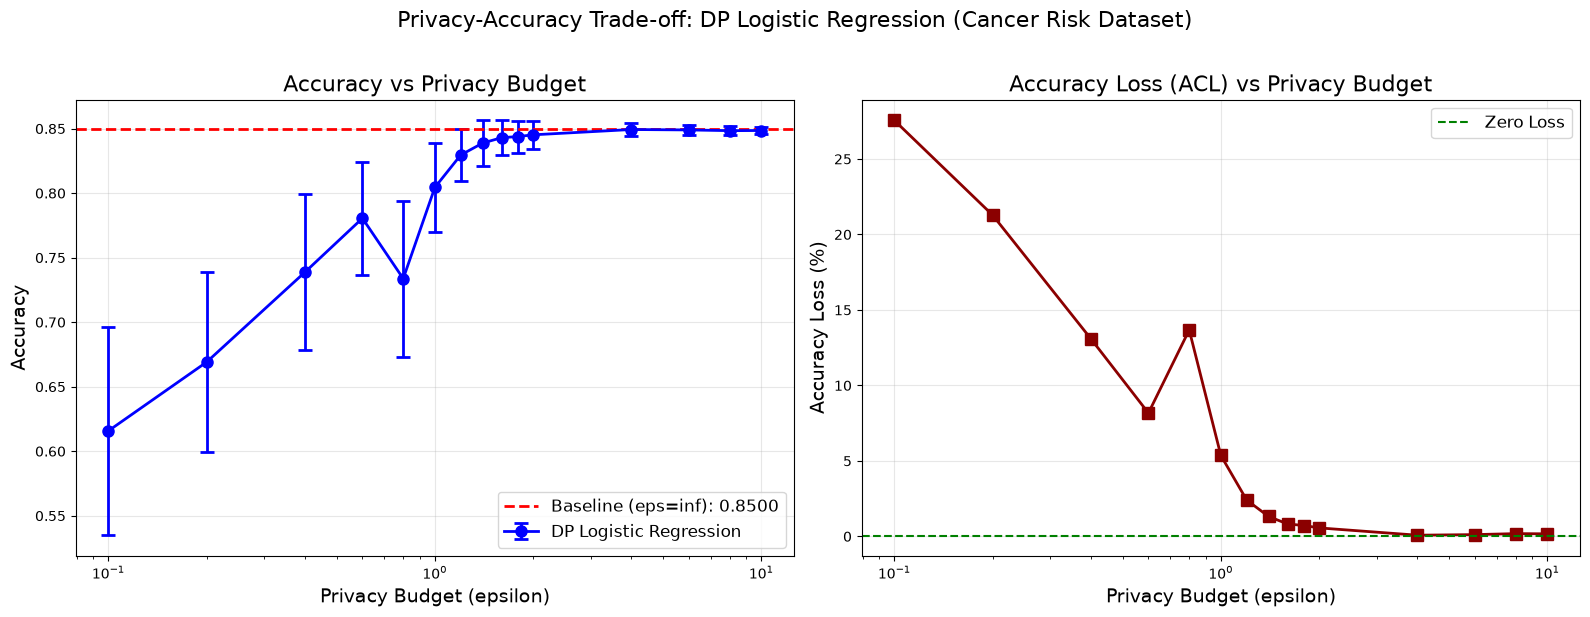

Plot saved to ./output/privacy_accuracy_tradeoff.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Epsilon vs Accuracy with error bars
axes[0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                 yerr=results_df['accuracy_std'],
                 marker='o', capsize=5, capthick=2, linewidth=2, markersize=8,
                 label='DP Logistic Regression', color='blue')
axes[0].axhline(y=baseline_accuracy, color='red', linestyle='--',
                linewidth=2, label=f'Baseline (eps=inf): {baseline_accuracy:.4f}')
axes[0].set_xlabel('Privacy Budget (epsilon)', fontsize=14)
axes[0].set_ylabel('Accuracy', fontsize=14)
axes[0].set_title('Accuracy vs Privacy Budget', fontsize=16)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Subplot 2: Epsilon vs Accuracy Loss
axes[1].plot(results_df['epsilon'], results_df['accuracy_loss_pct'],
             marker='s', linewidth=2, markersize=8, color='darkred')
axes[1].axhline(y=0, color='green', linestyle='--', linewidth=1.5, label='Zero Loss')
axes[1].set_xlabel('Privacy Budget (epsilon)', fontsize=14)
axes[1].set_ylabel('Accuracy Loss (%)', fontsize=14)
axes[1].set_title('Accuracy Loss (ACL) vs Privacy Budget', fontsize=16)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

plt.suptitle('Privacy-Accuracy Trade-off: DP Logistic Regression (Cancer Risk Dataset)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('./output/privacy_accuracy_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to ./output/privacy_accuracy_tradeoff.png")

## 10. Visualization - All Metrics vs Epsilon

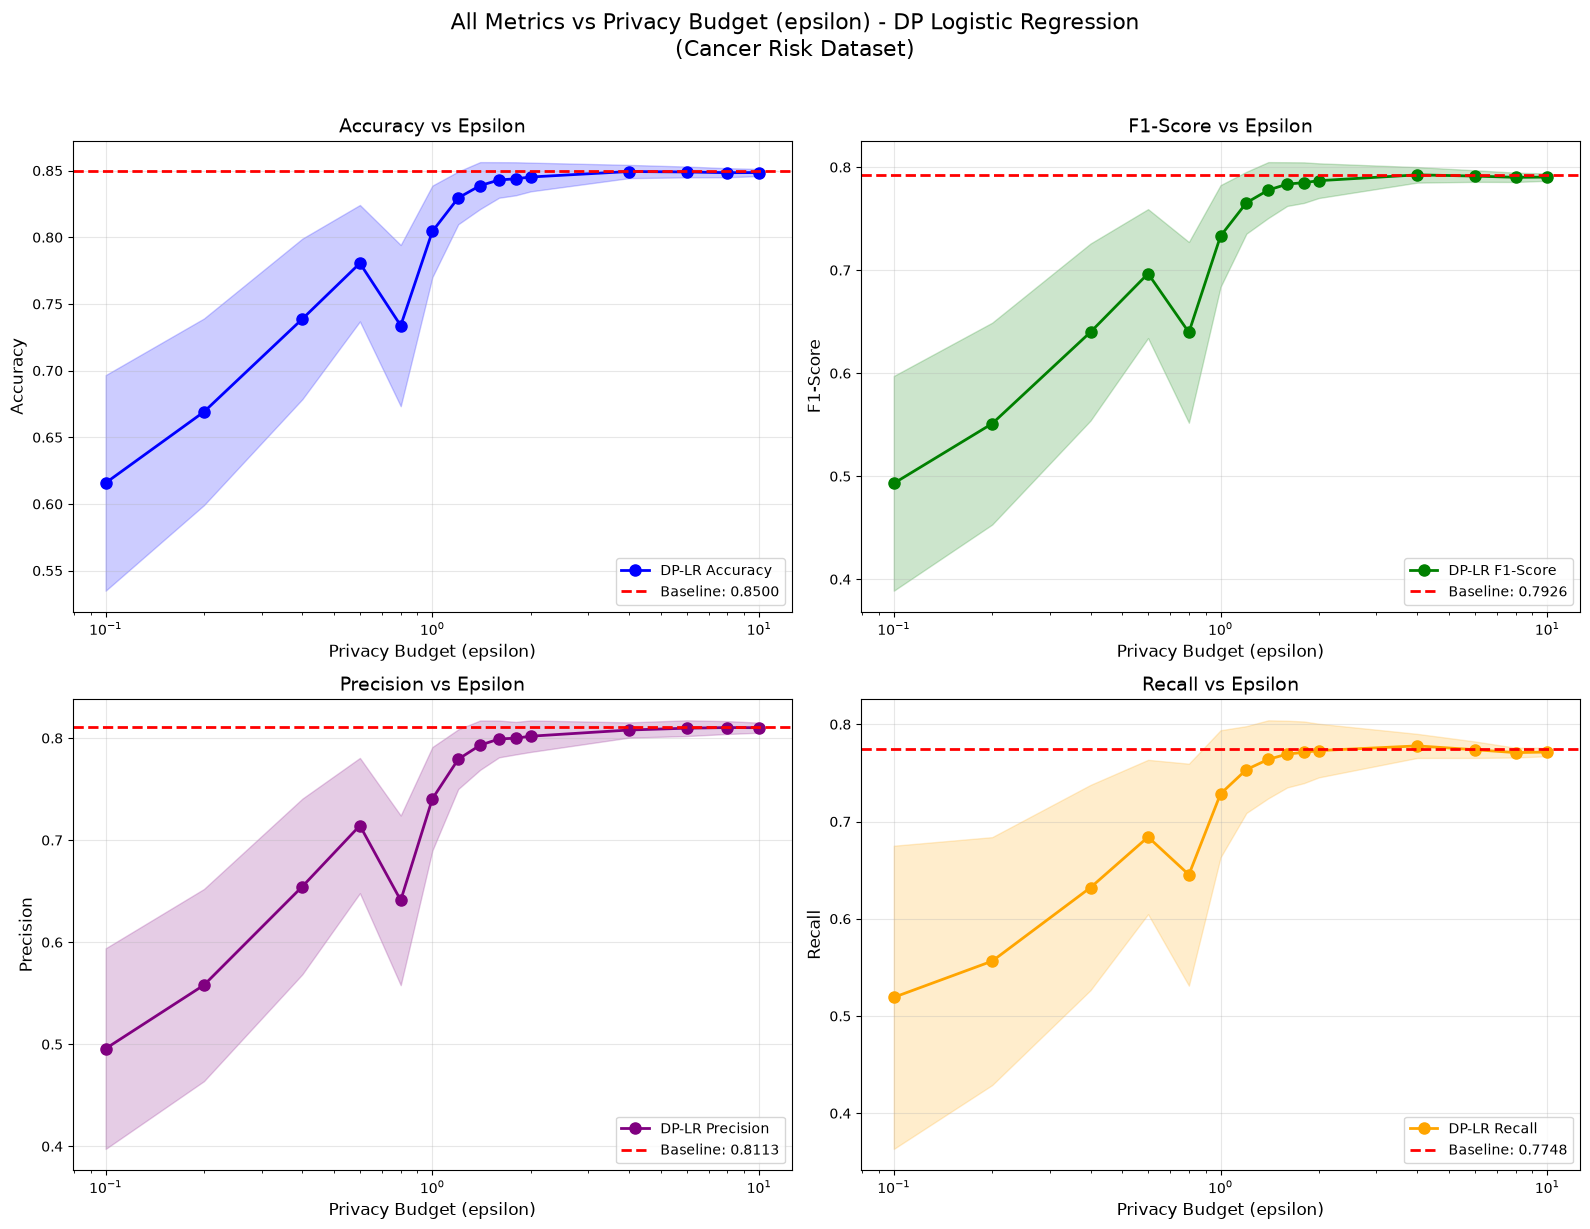

Plot saved to ./output/all_metrics_vs_epsilon.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_config = [
    ('accuracy_mean', 'accuracy_std', 'Accuracy', baseline_accuracy, 'blue'),
    ('f1_score_mean', 'f1_score_std', 'F1-Score', baseline_f1, 'green'),
    ('precision_mean', 'precision_std', 'Precision', baseline_precision, 'purple'),
    ('recall_mean', 'recall_std', 'Recall', baseline_recall, 'orange'),
]

for idx, (mean_col, std_col, label, baseline_val, color) in enumerate(metrics_config):
    ax = axes[idx // 2, idx % 2]

    mean_vals = results_df[mean_col].values
    std_vals = results_df[std_col].values
    eps_vals = results_df['epsilon'].values

    # Plot with shaded confidence bands
    ax.plot(eps_vals, mean_vals, marker='o', linewidth=2, markersize=8,
            color=color, label=f'DP-LR {label}')
    ax.fill_between(eps_vals, mean_vals - std_vals, mean_vals + std_vals,
                    alpha=0.2, color=color)

    # Baseline horizontal line
    ax.axhline(y=baseline_val, color='red', linestyle='--', linewidth=2,
               label=f'Baseline: {baseline_val:.4f}')

    ax.set_xlabel('Privacy Budget (epsilon)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} vs Epsilon', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')

plt.suptitle('All Metrics vs Privacy Budget (epsilon) - DP Logistic Regression\n(Cancer Risk Dataset)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('./output/all_metrics_vs_epsilon.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to ./output/all_metrics_vs_epsilon.png")

## 11. Final Summary

In [13]:
print("\n" + "=" * 70)
print("DIFFERENTIALLY PRIVATE LOGISTIC REGRESSION - FINAL SUMMARY")
print("=" * 70)
print(f"Dataset: Cancer Risk Prediction ({X_train.shape[0] + X_test.shape[0]} samples, {X_train.shape[1]} features)")
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Epsilon values tested: {len(epsilon_values)}")
print(f"Runs per epsilon: {N_RUNS}")
print(f"\nBest DP accuracy: {results_df['accuracy_mean'].max():.4f} at epsilon={results_df.loc[results_df['accuracy_mean'].idxmax(), 'epsilon']:.1f}")
print(f"Worst DP accuracy: {results_df['accuracy_mean'].min():.4f} at epsilon={results_df.loc[results_df['accuracy_mean'].idxmin(), 'epsilon']:.1f}")
print(f"\nAccuracy Loss Range: {results_df['accuracy_loss_pct'].min():.2f}% to {results_df['accuracy_loss_pct'].max():.2f}%")
print(f"\nFiles saved:")
print(f"  - output/dp_lr_report.json (detailed per-run results)")
print(f"  - output/dp_results.csv (aggregated results table)")
print(f"  - output/privacy_accuracy_tradeoff.png")
print(f"  - output/all_metrics_vs_epsilon.png")
print("=" * 70)


DIFFERENTIALLY PRIVATE LOGISTIC REGRESSION - FINAL SUMMARY
Dataset: Cancer Risk Prediction (1500 samples, 8 features)
Baseline Accuracy: 0.8500
Epsilon values tested: 15
Runs per epsilon: 30

Best DP accuracy: 0.8493 at epsilon=4.0
Worst DP accuracy: 0.6158 at epsilon=0.1

Accuracy Loss Range: 0.08% to 27.56%

Files saved:
  - output/dp_lr_report.json (detailed per-run results)
  - output/dp_results.csv (aggregated results table)
  - output/privacy_accuracy_tradeoff.png
  - output/all_metrics_vs_epsilon.png
